In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import display

In [3]:
#input_path = Path("ARR_MARCH") / "Output" / "summaries" / "Ablation" / "CC_VE_PROMPTED"
input_path = Path(r"C:\Users\kpoth\Downloads\CCT\GitHub\cct-python\ARR_MARCH\Output\summaries\Ablation\CC_VE_PROMPTED")

In [4]:
single_culture = ['Japan', 'Armenia', 'Germany', 'Greece', 'Netherlands']

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
domain_files = {
    "SCTOM": [
        "CCT_METRICS_COMBINED_SCTOM_I.csv", 
        "CCT_METRICS_COMBINED_SCTOM_II.csv", 
        "CCT_METRICS_COMBINED_SCTOM_III.csv"
    ],
    "SVNS": [
        "CCT_METRICS_COMBINED_SVNS_I.csv", 
        "CCT_METRICS_COMBINED_SVNS_II.csv", 
        "CCT_METRICS_COMBINED_SVNS_III.csv"
    ],
    "PIPP": [
        "CCT_METRICS_COMBINED_PIPP_I.csv", 
        "CCT_METRICS_COMBINED_PIPP_II.csv"
    ],
    "PCPR": [
        "CCT_METRICS_COMBINED_PCPR_I.csv", 
        "CCT_METRICS_COMBINED_PCPR_II.csv"
    ]
}

In [7]:
num_cols = ['variance_explained', 'eig_ratio', 'comp_raw_mean', 'comp_q99_mean', 'pct_agreement_consensus']

In [8]:
for domain_name, file_list in domain_files.items():
    print(f"Processing {domain_name}...")
    
    # Read and concatenate all sub-files for the current domain
    df_list = [pd.read_csv(f'{input_path}/{f}') for f in file_list]
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # Ensure our target columns are perfectly numeric
    for col in num_cols:
        if col in combined_df.columns:
            combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')
    
    # Group by the identifiers and average, keeping NA prompts intact for humans
    aggregated_df = combined_df.groupby(
        ['country', 'group', 'prompt'], dropna=False
    )[num_cols].mean().reset_index()
    
    # Set the overarching domain name
    aggregated_df['domain'] = domain_name
    
    # Save the finalized, aggregated CSV for this domain
    output_filename = f"{input_path}/CCT_METRICS_COMBINED_{domain_name}.csv"
    aggregated_df.to_csv(output_filename, index=False)
    
    print(f"Saved aggregated file: {output_filename}\n")

Processing SCTOM...
Saved aggregated file: C:\Users\kpoth\Downloads\CCT\GitHub\cct-python\ARR_MARCH\Output\summaries\Ablation\CC_VE_PROMPTED/CCT_METRICS_COMBINED_SCTOM.csv

Processing SVNS...
Saved aggregated file: C:\Users\kpoth\Downloads\CCT\GitHub\cct-python\ARR_MARCH\Output\summaries\Ablation\CC_VE_PROMPTED/CCT_METRICS_COMBINED_SVNS.csv

Processing PIPP...
Saved aggregated file: C:\Users\kpoth\Downloads\CCT\GitHub\cct-python\ARR_MARCH\Output\summaries\Ablation\CC_VE_PROMPTED/CCT_METRICS_COMBINED_PIPP.csv

Processing PCPR...
Saved aggregated file: C:\Users\kpoth\Downloads\CCT\GitHub\cct-python\ARR_MARCH\Output\summaries\Ablation\CC_VE_PROMPTED/CCT_METRICS_COMBINED_PCPR.csv



In [9]:
aggregated_files = [
    "CCT_METRICS_COMBINED_SCTOM.csv",
    "CCT_METRICS_COMBINED_SVNS.csv",
    "CCT_METRICS_COMBINED_PIPP.csv",
    "CCT_METRICS_COMBINED_PCPR.csv"
]

single_files = [
    "CCT_METRICS_COMBINED_POST.csv", 
    "CCT_METRICS_COMBINED_POS.csv", 
    "CCT_METRICS_COMBINED_POC.csv", 
    "CCT_METRICS_COMBINED_POM.csv", 
    "CCT_METRICS_COMBINED_EV.csv", 
    "CCT_METRICS_COMBINED_EVN.csv", 
    "CCT_METRICS_COMBINED_RV.csv", 
    "CCT_METRICS_COMBINED_HWB.csv"
]



In [10]:
all_dataframes = []

for file in aggregated_files:
    df = pd.read_csv(f'{input_path}/{file}')
    all_dataframes.append(df)
    print(f"Loaded {file}")

Loaded CCT_METRICS_COMBINED_SCTOM.csv
Loaded CCT_METRICS_COMBINED_SVNS.csv
Loaded CCT_METRICS_COMBINED_PIPP.csv
Loaded CCT_METRICS_COMBINED_PCPR.csv


In [11]:
for file in single_files:
    df = pd.read_csv(f'{input_path}/{file}')
    domain_name = file.replace("CCT_METRICS_COMBINED_", "").replace(".csv", "")
    
    df['domain'] = domain_name
    all_dataframes.append(df)
    print(f"Loaded {file} (Domain assigned: {domain_name})")

Loaded CCT_METRICS_COMBINED_POST.csv (Domain assigned: POST)
Loaded CCT_METRICS_COMBINED_POS.csv (Domain assigned: POS)
Loaded CCT_METRICS_COMBINED_POC.csv (Domain assigned: POC)
Loaded CCT_METRICS_COMBINED_POM.csv (Domain assigned: POM)
Loaded CCT_METRICS_COMBINED_EV.csv (Domain assigned: EV)
Loaded CCT_METRICS_COMBINED_EVN.csv (Domain assigned: EVN)
Loaded CCT_METRICS_COMBINED_RV.csv (Domain assigned: RV)
Loaded CCT_METRICS_COMBINED_HWB.csv (Domain assigned: HWB)


In [12]:
final_master_df = pd.concat(all_dataframes, ignore_index=True)

In [13]:
single_culture_countries = ['Armenia', 'Japan', 'Greece', 'Germany', 'Netherlands'] 
multi_culture_countries = ['Colombia', 'Mexico', 'Peru', 'United_States', 'Malaysia']

In [14]:
def assign_culture_type(country):
    if country in single_culture_countries:
        return 'Single-Culture'
    elif country in multi_culture_countries:
        return 'Multi-Culture'
    else:
        return 'Unknown'

final_master_df['culture_type'] = final_master_df['country'].apply(assign_culture_type)

In [15]:
human_df = final_master_df[final_master_df['group'] == 'human'][['domain', 'country', 'culture_type', 'variance_explained']].copy()
human_df = human_df.rename(columns={'variance_explained': 'human_variance'})

llm_df = final_master_df[final_master_df['group'] == 'llm'][['domain', 'country', 'culture_type', 'prompt', 'variance_explained', 'pct_agreement_consensus']].copy()
llm_df = llm_df.rename(columns={'variance_explained': 'llm_variance'})
llm_df['pct_agreement_consensus'] = pd.to_numeric(llm_df['pct_agreement_consensus'], errors='coerce')

# Merge and calculate
plot_data = pd.merge(llm_df, human_df, on=['domain', 'country', 'culture_type'], how='left')
plot_data['delta_ve'] = plot_data['llm_variance'] - plot_data['human_variance']
plot_data['cc_score'] = plot_data['pct_agreement_consensus'] / 100.0

In [16]:
plot_data = plot_data.dropna(subset=['delta_ve', 'cc_score'])

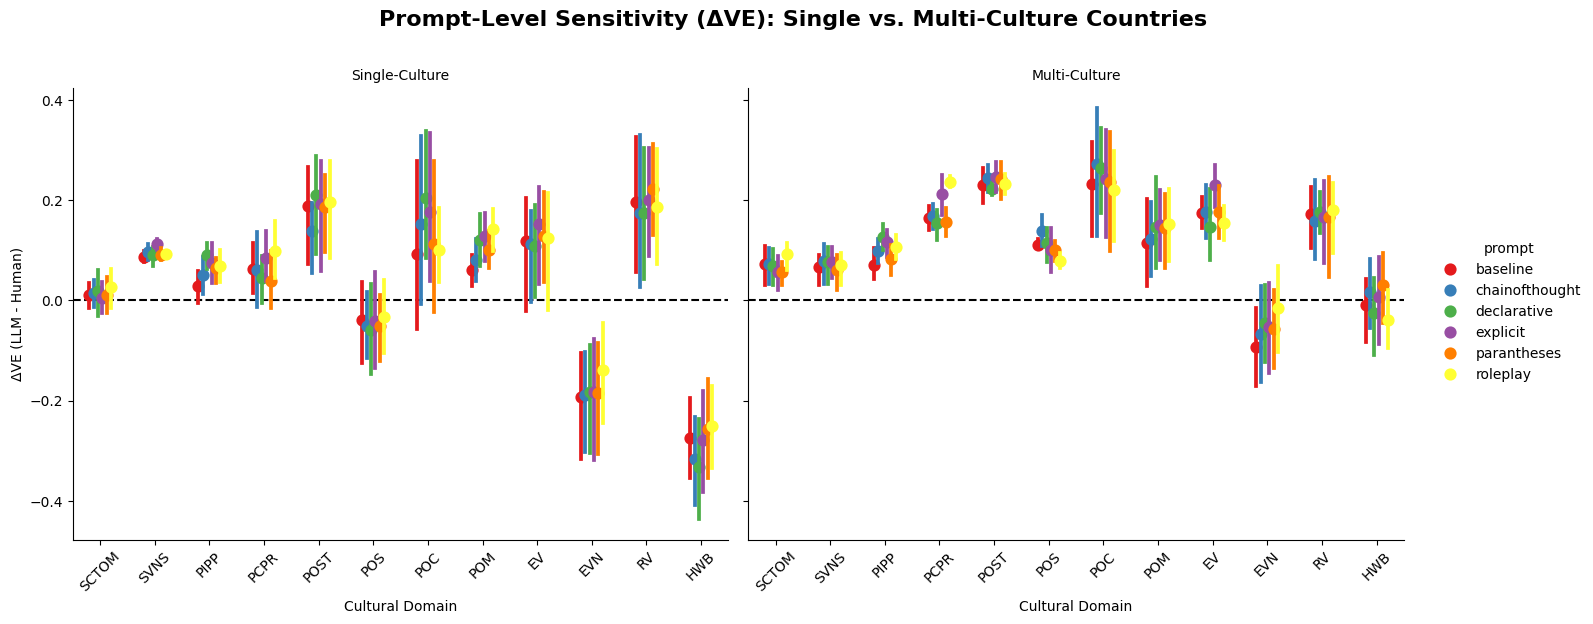

In [17]:
g = sns.catplot(
    data=plot_data,
    x='domain',
    y='delta_ve',
    hue='prompt',
    col='culture_type',
    kind='point',            
    dodge=0.4,               
    errorbar='ci',            
    markers='o',
    linestyles='',           
    palette='Set1',
    height=6,
    aspect=1.2,
    sharey=True
)

# Add a dashed line at 0 (Human baseline) across all panels
g.map(plt.axhline, y=0, ls='--', c='black', linewidth=1.5, zorder=0)

# Formatting the titles and labels
g.set_axis_labels("Cultural Domain", "\u0394VE (LLM - Human)")
g.set_titles("{col_name}") 

# Rotate the X-axis labels for readability in all subplots
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelrotation=45)

plt.subplots_adjust(top=0.85) 
g.figure.suptitle('Prompt-Level Sensitivity (\u0394VE): Single vs. Multi-Culture Countries', fontsize=16, fontweight='bold')

plt.show()

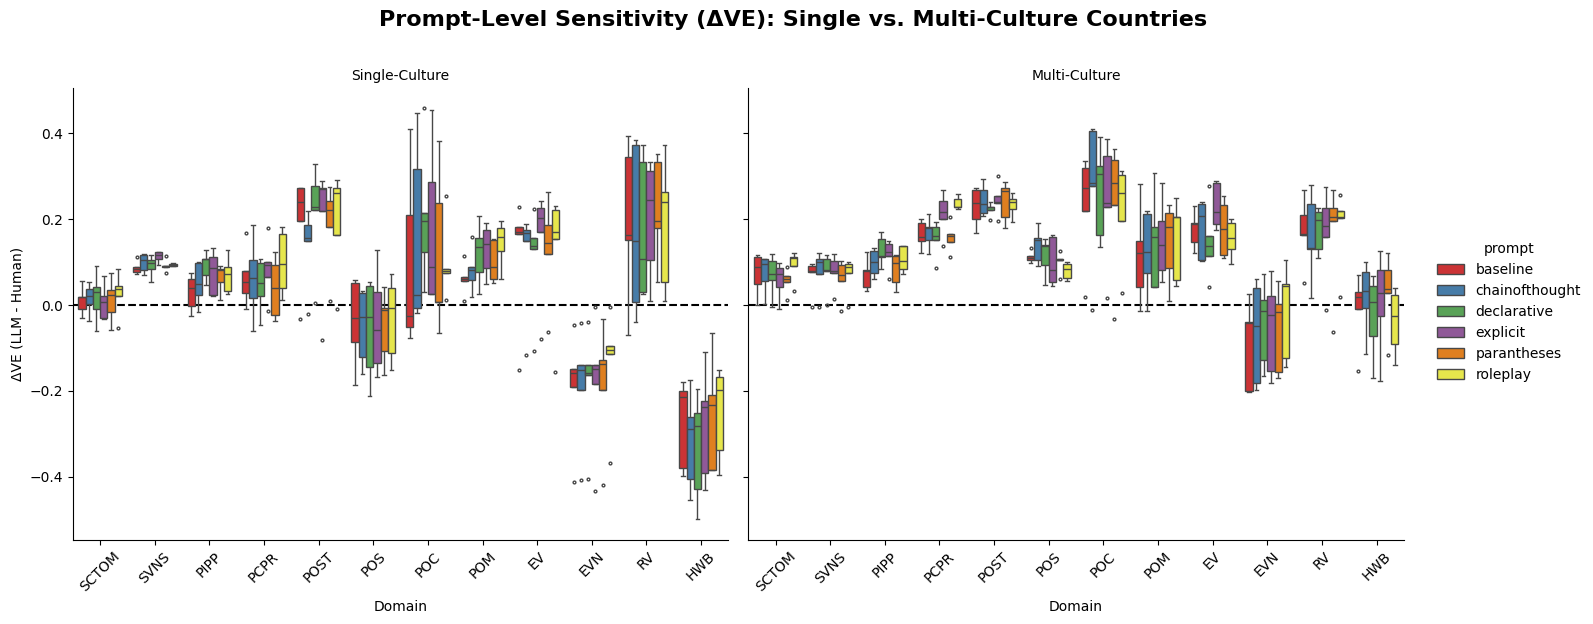

In [19]:
g = sns.catplot(
    data=plot_data,
    x='domain',
    y='delta_ve',
    hue='prompt',
    col='culture_type',
    kind='box',              
    fliersize=2,              
    linewidth=1,              
    palette='Set1',
    height=6,
    aspect=1.2,
    sharey=True
)
g.map(plt.axhline, y=0, ls='--', c='black', linewidth=1.5, zorder=0)

# Formatting the titles and labels
g.set_axis_labels("Domain", "\u0394VE (LLM - Human)")
g.set_titles("{col_name}") 

# Rotate the X-axis labels for readability in all subplots
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelrotation=45)

plt.subplots_adjust(top=0.85) 
g.figure.suptitle('Prompt-Level Sensitivity (\u0394VE): Single vs. Multi-Culture Countries', fontsize=16, fontweight='bold')

# Save the figure
plt.savefig('Output/plots/prompt_sensitivity_ve_culture_split.png', dpi=300, bbox_inches='tight')
plt.show()